# Hantavirus: analysis of data and modelling

Analysis of data for Hantavirus Andes (with possible transmission human-to-human).  

Content of the notebook:  
1) Supporting statistical analysis: interquartile range of ages of infected people.
2) Call to network model on Watts-Strogatz; exploration of its properties; test of superspreading options.
3) Fit network model to data (from 2018 outbreak and from 2026 outbreak); statistical consistency analysis.

The testing of scenarios is performed on the Hanta_scenarios.ipynb notebook.

## Imports

In [22]:
# Basics and statistics
from scipy.stats import iqr
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import nbinom
from scipy.optimize import minimize

import pandas as pd
import numpy as np
import datetime
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Custom simulation functions
from src.epidemic_seir_smallworld import run_seir
from src.epidemic_seir_smallworld import print_report

# Custom fitting functions
from src.fit_r0 import fit_r0, load_data, save_fitted_curve, plot_fit, FitResult
from src.fit_infec_per import fit_infectious_period, load_data, plot_fit
from src.fit_r0_scalefree import abc_rejection

from print_versions import print_versions

## Defs

In [23]:
# Plot time series
def plot_tseries(n_nodes: int,
    R0: float,
    incubation_days: float,
    infectious_days: float,
    superspreading: bool,
    k_disp: float,
    S: list[int],
    E: list[int],
    I: list[int],
    R: list[int],
    ss: list[int]):
    
            days = list(range(len(S)))
            has_ss_events = superspreading and any(ss)

            if has_ss_events:
                fig = plt.figure(figsize=(11, 6))
                gs  = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.4)
                ax1 = fig.add_subplot(gs[0])
                ax2 = fig.add_subplot(gs[1], sharex=ax1)
            else:
                fig, ax1 = plt.subplots(figsize=(10, 5))
                ax2 = None

            ax1.plot(days, S, label="Susceptible (S)", color="#2196F3", linewidth=2)
            ax1.plot(days, E, label="Exposed     (E)", color="#FF9800", linewidth=2, linestyle="--")
            ax1.plot(days, I, label="Infectious  (I)", color="#F44336", linewidth=2)
            ax1.plot(days, R, label="Recovered   (R)", color="#4CAF50", linewidth=2)
            ax1.set_ylabel("Count", fontsize=15)
            ss_tag = f", superspreading k={k_disp}" if superspreading else ""
            ax1.legend()
            ax1.grid(alpha=0.3)

            if ax2 is not None:
                ax2.bar(days, ss, color="#9C27B0", alpha=0.75,
                        label="Superspreader events / day")
                ax2.set_xlabel("Day")
                ax2.set_ylabel("Events")
                ax2.legend(fontsize=8)
                ax2.grid(alpha=0.3)
            else:
                ax1.set_xlabel("Day", fontsize=15)

            plt.tight_layout()
            plt.show()

# Akaike information criterion (AIC) score
def akaike_score(y, y_pred, n_params, n_data):
    residuals = y - y_pred
    sse = np.sum(residuals ** 2)

    log_likelihood = -n_data / 2 * np.log(2 * np.pi * sse / n_data) - n_data / 2
    aic = 2 * n_params - 2 * log_likelihood
    return aic

# Dates of cases, relative to index case
def dates_to_intervals(dates):
    parsed = [datetime.datetime.strptime(d, '%Y-%m-%d') for d in dates]
    return [(d - parsed[0]).days for d in parsed]

# Meta-analysis to combine R0 and its uncertainty
def weighted_stats(R0s, sigmas):
    weights = 1/np.pow(sigmas,2)
    combined_mean = np.sum(weights * R0s) / np.sum(weights)
    combined_sd = np.sqrt(1 / np.sum(weights))
    combined_lower95 = combined_mean - 1.96 * combined_sd
    combined_upper95 = combined_mean + 1.96 * combined_sd
    return [combined_mean, combined_sd, combined_lower95, combined_upper95]

## 1) Statistical and summary analysis

### Time series for the three recorded human-to-human H. andes outbreaks
From Wells et al. (1997) (outbreak of 1996), Martinex et al (2020) (outbreak of 2018) and the recent MV Hondius outbreak (2026).  
Reported, time series of symptom onsets (detection) for each of the three outbreaks, with normalised time series

In [24]:
# Data

time_1997 = ['1996-09-22', '1996-09-23', '1996-10-04', '1996-10-12', '1996-10-13', '1996-10-21', '1996-10-22', '1996-10-23', '1996-10-31', '1996-11-04', '1996-11-07', '1996-11-08', '1996-11-28', '1996-12-05']
time_2020 = ['2018-11-03', '2018-11-20', '2018-11-23', '2018-11-25',  '2018-11-26',  '2018-11-27',  '2018-12-07', '2018-12-10', '2018-12-12', '2018-12-13', '2018-12-15', '2018-12-19', '2018-12-24', '2018-12-26', '2018-12-28', '2018-12-31', '2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04', '2019-01-06', '2019-01-07', '2019-01-08', '2019-01-14', '2019-01-21', '2019-01-24', '2019-01-29', '2019-02-06']
time_2026 = ['2026-04-06', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-30', '2026-05-01', '2026-05-11', '2026-05-12', '2026-05-14', '2026-05-22', '2026-05-25']

cases_1997 = [1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1]
cases_2020 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2]
cases_2026 = [1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1]

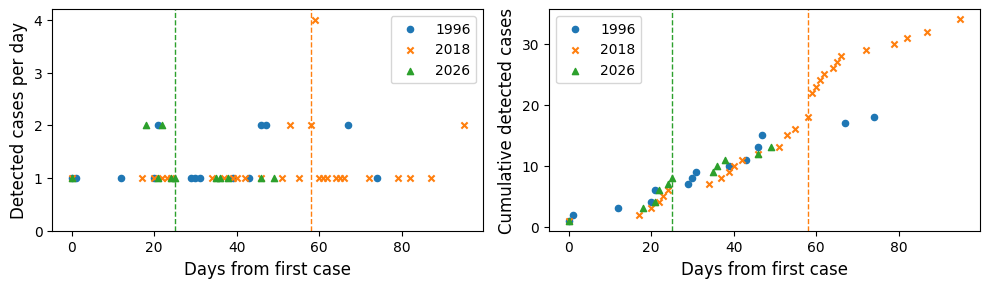

In [25]:
# Manage data to be comparable

df_1997 = pd.to_datetime(time_1997)
diffs_1997 = dates_to_intervals(time_1997)

df_2020 = pd.to_datetime(time_2020)
diffs_2020 = dates_to_intervals(time_2020)

df_2026 = pd.to_datetime(time_2026)
diffs_2026 = dates_to_intervals(time_2026)

# Date of interventions (days from first case) for 2018 and 2026 (unknown for 1996)
interventions_2018 = 58
interventions_2026 = 25


# Plot incidence and cumulative cases, for the three outbreaks

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

axes[0].scatter(diffs_1997, cases_1997, marker='o', label="1996", s = 20)
axes[0].scatter(diffs_2020, cases_2020, marker='x', label= "2018", s = 20)
axes[0].scatter(diffs_2026, cases_2026, marker='^', label= "2026", s = 20)
axes[0].axvline(x=interventions_2018, color='C1', linestyle='--', linewidth=1)
axes[0].axvline(x=interventions_2026, color='C2', linestyle='--', linewidth=1)
axes[0].set_ylim([0,4.2])
axes[0].set_xlabel("Days from first case", fontsize=12)
axes[0].set_ylabel("Detected cases per day", fontsize=12)
axes[0].legend()

axes[1].scatter(diffs_1997, np.cumsum(cases_1997), marker='o', label="1996", s = 20)
axes[1].scatter(diffs_2020, np.cumsum(cases_2020), marker='x', label= "2018", s = 20)
axes[1].scatter(diffs_2026, np.cumsum(cases_2026), marker='^', label= "2026", s = 20)
axes[1].axvline(x=interventions_2018, color='C1', linestyle='--', linewidth=1)
axes[1].axvline(x=interventions_2026, color='C2', linestyle='--', linewidth=1)
axes[1].set_xlabel("Days from first case", fontsize=12)
axes[1].set_ylabel("Cumulative detected cases", fontsize=12)
axes[1].legend()
fig.tight_layout()
#fig.savefig('figures/data_outbreaks_both.pdf', bbox_inches='tight')


### Analysis of age (always round up to ceil)

Mean and inter-quartile range of age for 2026 cases

In [26]:
data = [70, 69, 69, 65, 41, 56, 65, 70, 70] # from https://en.wikipedia.org/wiki/MV_Hondius_hantavirus_outbreak
print(f"Mean: {np.mean(data)}, IQR: {iqr(data)}")

Mean: 63.888888888888886, IQR: 5.0


Mean and inter-quartile range of age for 2026 deaths

In [27]:
data = [70, 69, 65] # from https://en.wikipedia.org/wiki/MV_Hondius_hantavirus_outbreak
print(f"Mean: {np.mean(data)}, IQR: {iqr(data)}")

Mean: 68.0, IQR: 2.5


Mean and inter-quartile range of age for 2018 deaths (cross-referenced from Martizes et al, Suup Mat, and Table S1)

In [28]:
data = [61,14,72,38,30,65,34,58,41,38]
print(f"Mean: {np.mean(data)}, IQR: {iqr(data)}")

Mean: 45.1, IQR: 25.25


(array([0.01724138, 0.        , 0.01724138, 0.01724138, 0.05172414,
        0.        , 0.        , 0.01724138, 0.03448276, 0.01724138]),
 array([14. , 19.8, 25.6, 31.4, 37.2, 43. , 48.8, 54.6, 60.4, 66.2, 72. ]),
 <BarContainer object of 10 artists>)

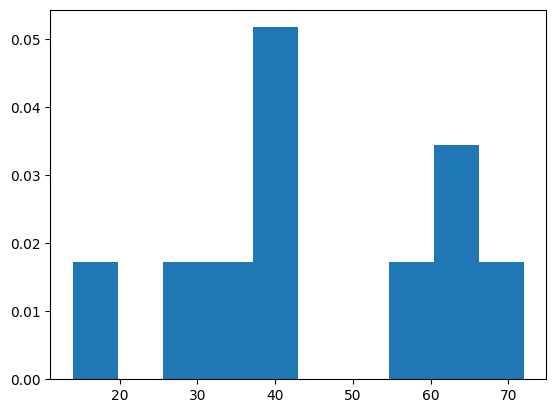

In [29]:
plt.hist(data, density=True,)

Mean and inter-quartile range of age for 1996 deaths (from Wells et al.)

In [30]:
data = [41,27,26,70,40,40]
print(f"Mean: {np.mean(data)}, IQR: {iqr(data)}")

Mean: 40.666666666666664, IQR: 10.5


### Distribution of superspreaders in 2018's outbreak

(array([7., 1., 2., 0., 1., 1., 0., 0., 0., 1.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

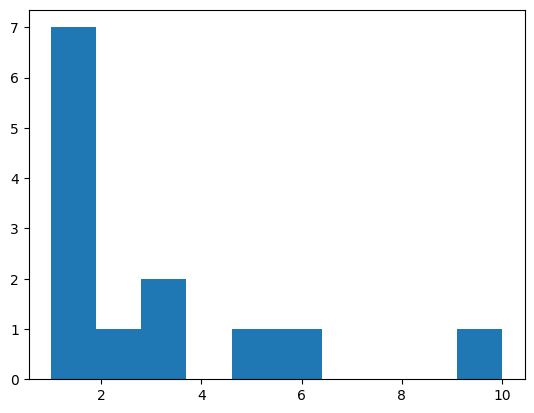

In [31]:
# Number of offsprings from every contact in the reconstructed chain of contagion. Counts from Fig. 1B of Martinez2020); it includes possible sources (yellow arrows)
Z = [5, 6, 1, 1, 10, 1, 1, 1, 3, 3, 1, 2, 1]
df = pd.DataFrame({'count': Z})

plt.hist(Z)

#### Fit negative binomial
Also plot it and calculate AIC score

In [32]:
nb_model = smf.negativebinomial(formula='count ~ 1', data=df).fit()

# Extract parameters
# params[0] is log(mu), params[1] is alpha (dispersion)
log_mu = nb_model.params.iloc[0]
alpha = nb_model.params.iloc[1]

mu = np.exp(log_mu)
var = mu + alpha * mu**2

# Convert to scipy.stats.nbinom parameters (n, p): scipy uses 'n' for the number of successes and 'p' for probability of success (this way I can pass to scipy for plotting)
n_est = mu**2 / (var - mu)
p_est = mu / var

lower, upper = nbinom.ppf([0.025, 0.975], n_est, p_est)

print(f"Mean (mu): {mu:.4f}")
print(f"Var (var): {var:.4f}")
print(f"Dispersion (alpha): {alpha:.4f}")
print(f"Scipy n (successes): {n_est:.4f}")
print(f"Scipy p (probability): {p_est:.4f}")
print(f"95% CI: {lower:.4f}, {upper:.4f}")

Optimization terminated successfully.
         Current function value: 2.095805
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
Mean (mu): 2.7692
Var (var): 5.7937
Dispersion (alpha): 0.3944
Scipy n (successes): 2.5355
Scipy p (probability): 0.4780
95% CI: 0.0000, 9.0000


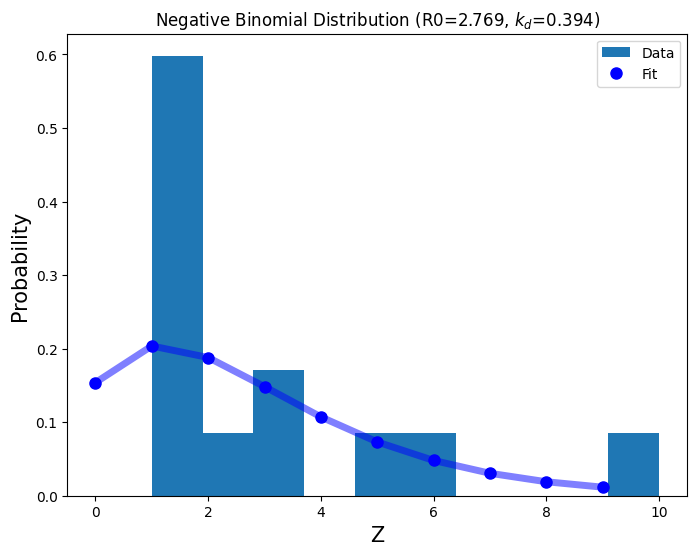

In [33]:
# Calculate range for x-axis (number of failures)
x = np.arange(nbinom.ppf(0.01, n_est, p_est), nbinom.ppf(0.99, n_est, p_est))

# Calculate PMF
y = nbinom.pmf(x, n_est, p_est)

# Plot
plt.figure(figsize=(8, 6))
xx, bins, patches = plt.hist(Z,density=True, label='Data')
plt.plot(x, y, 'bo', ms=8, label='Fit')
plt.plot(x, y, color='b', lw=5, alpha=0.5)
plt.xlabel('Z', fontsize=15)
plt.ylabel('Probability', fontsize=15)
plt.title(f'Negative Binomial Distribution (R0={round(mu,3)}, $k_d$={round(alpha,3)})')
plt.legend()
plt.savefig('figures/fit_Z2018_neg_binom.svg', bbox_inches='tight')
plt.show()


In [34]:
# Akaike AIC score for negative binomial
akaike_score(xx, y, 2, len(x))

np.float64(-4.775823938287772)

#### Fit Poisson

Fitted Lambda: 2.77


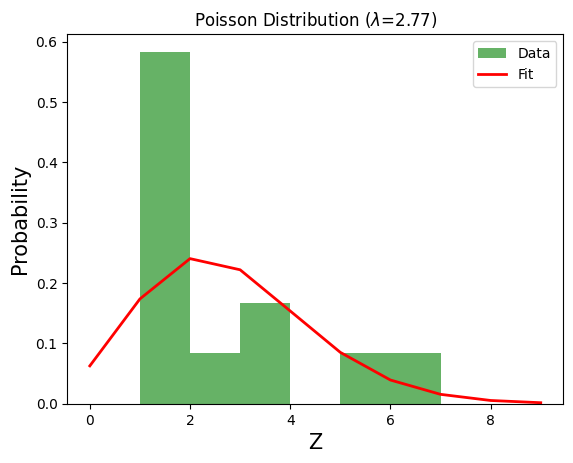

In [35]:
def neg_log_likelihood(params, data):
    lamb = params[0]
    # Use scipy's built-in logpmf for numerical stability
    return -np.sum(stats.poisson.logpmf(data, lamb))

# 3. Optimize to find best lambda
initial_guess = [np.mean(Z)]
result = minimize(neg_log_likelihood, initial_guess, args=(Z,), method='Powell')
fitted_lambda = result.x[0]

print(f"Fitted Lambda: {fitted_lambda:.2f}")

# 4. Plot
x = np.arange(0, 10)
yyy = stats.poisson.pmf(x, fitted_lambda)
plt.hist(Z, bins=range(0, 10), density=True, alpha=0.6, color='g', label='Data')
plt.plot(x, stats.poisson.pmf(x, fitted_lambda), 'r-', lw=2, label=f'Fit')
plt.title(f'Poisson Distribution ($λ$={fitted_lambda:.2f})')
plt.xlabel('Z', fontsize=15)
plt.ylabel('Probability', fontsize=15)
plt.legend()
plt.savefig('figures/fit_Z2018_poisson.svg', bbox_inches='tight')
plt.show()


In [36]:
# Akaike AIC score for negative binomial
akaike_score(xx, yyy, 1, len(x))

np.float64(-2.8024559327048557)

## 2) Play with network model
Get a sense of what it does and how it evolves; only used for preliminary tests.

### Values from literature (from 2018 outbreak and Cui2026); no superpreading
Default run


  SEIR Epidemic – Small-World Network
  Nodes              : 150
  R0                 : 2.5
  Incubation period  : 18 days
  Infectious period  : 12 days
  Superspreading     : OFF (homogeneous β)
  Duration           : 530 days
  Peak exposed  (E)  : 10  (day 128)
  Peak infectious(I) : 8  (day 130)
  Total ever infected: 135  (90.0% attack rate)



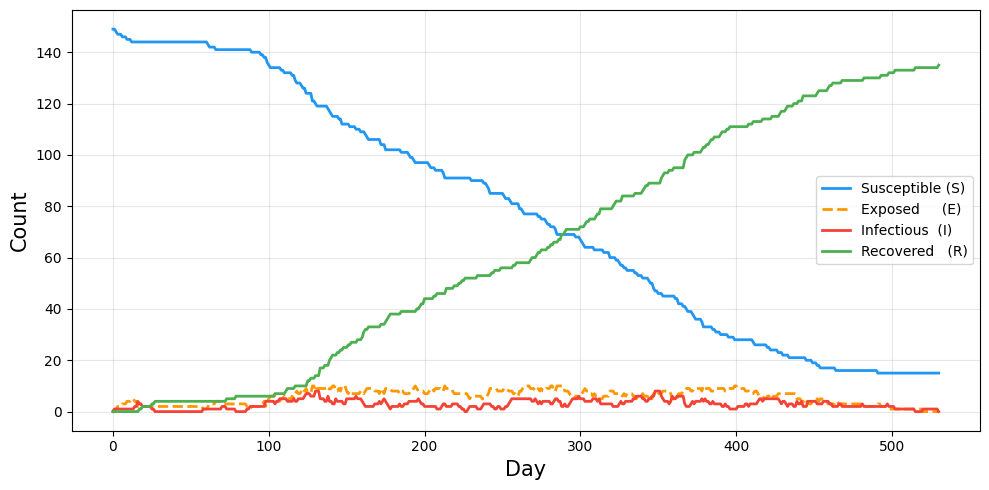

In [37]:
n_nodes = 150        # MV Hondius size
R0 = 2.5             # Between 2018's (2.12) and Cui's (2.76)
incubation_days = 18  # median
infectious_days = 12   # median by Cui(2026)
superspreading = False
k_disp = 0

S, E, I, R, ss = run_seir(
            n_nodes         = n_nodes,
            R0              = R0,
            incubation_days = incubation_days,
            infectious_days = infectious_days,
            superspreading  = superspreading
        )

print_report(n_nodes, R0, incubation_days, infectious_days,
        superspreading, k_disp,
        S, E, I, R, ss)

plot_tseries(n_nodes, R0, incubation_days, infectious_days,
        superspreading, k_disp,
        S, E, I, R, ss)

## 3) Fitting

### Get infectious period
Obtain $\gamma^{-1}$ not by the fit in Cui(2026), but by fitting the 2018 outbreak, keeping $R_0$ as already estimated

In [38]:
# Fit infectious period from 2018 outbreak (I also use R0 and median incubation period from Martinez2020)

# This is the fit without the constraint over the serial interval
result = fit_infectious_period(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1],
    R0=2.12, incubation_days=18.0, n_nodes=200,
    TI_min = 7, TI_max = 14,
)
print(f"T_I = {result.TI_estimate:.2f} d  [{result.TI_ci_low:.2f}, {result.TI_ci_high:.2f}]")
print(f"Implied SI = {result.implied_SI:.2f} d")



  Fitting T_I  |  R0=2.12  T_E=18.0 d  T_I ∈ [7, 14] d
  No SI constraint
  Method: abc  n_samples=500  replicates=10

  [████████████████████████████████████████]  500/500  best T_I=8.50 d  d=0.002963
T_I = 9.86 d  [7.22, 13.33]
Implied SI = 22.93 d


In [39]:
# Fit infectious period from 2018 outbreak (I also use R0 and median incubation period from Martinez2020)ù
# Here, I use the value for R0 estimated from the offspring negative binomial distribution, still relative to the 2018 outbreak.

# This is the fit without the constraint over the serial interval
result = fit_infectious_period(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1],
    R0=2.77, incubation_days=18.0, n_nodes=200,
    TI_min = 7, TI_max = 14,
)
print(f"T_I = {result.TI_estimate:.2f} d  [{result.TI_ci_low:.2f}, {result.TI_ci_high:.2f}]")
print(f"Implied SI = {result.implied_SI:.2f} d")



  Fitting T_I  |  R0=2.77  T_E=18.0 d  T_I ∈ [7, 14] d
  No SI constraint
  Method: abc  n_samples=500  replicates=10

  [████████████████████████████████████████]  500/500  best T_I=8.50 d  d=0.002868
T_I = 9.86 d  [7.22, 13.48]
Implied SI = 22.93 d


  Saved: fit_ti_R277.svg


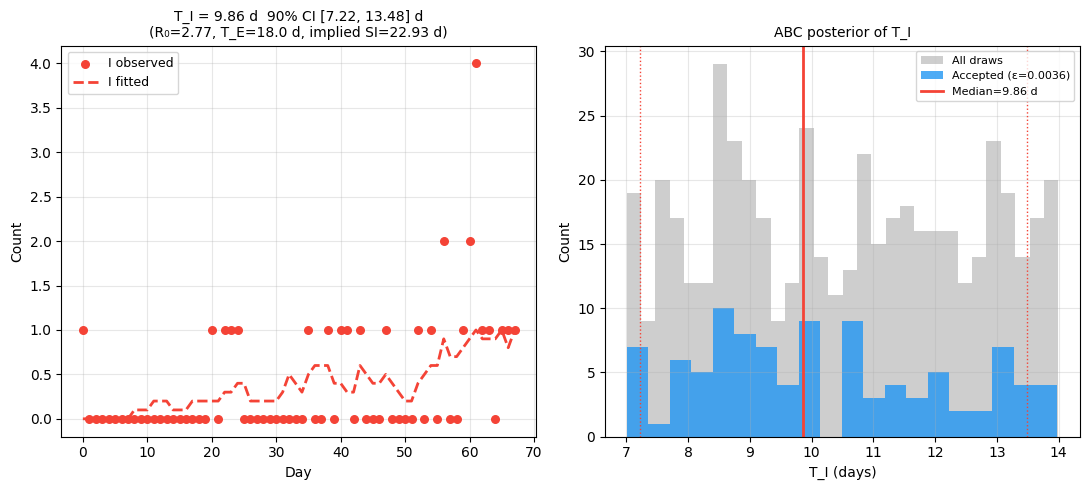

In [40]:
plot_fit(result, out_path="fit_ti_R277.svg")

In [41]:
# Now, I also impose a constraint on the serial interval (given by Martinez 2020), owing to the approximate formula
# T_Infectious = 2(SI − T_incubation)

''' # All commented to avoid runing it again when "run all". Just decomment to run it again
result = fit_infectious_period(
    I_obs = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1],
    R0=2.12, incubation_days=18.0,
    serial_interval=23, si_weight=0.3,
    TI_min=7, TI_max=14, n_samples=500,
)

print(f"T_I = {result.TI_estimate:.2f} d  [{result.TI_ci_low:.2f}, {result.TI_ci_high:.2f}]")
print(f"Implied SI = {result.implied_SI:.2f} d")
plot_fit(result, out_path="fit_ti.png")
'''

' # All commented to avoid runing it again when "run all". Just decomment to run it again\nresult = fit_infectious_period(\n    I_obs = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1],\n    R0=2.12, incubation_days=18.0,\n    serial_interval=23, si_weight=0.3,\n    TI_min=7, TI_max=14, n_samples=500,\n)\n\nprint(f"T_I = {result.TI_estimate:.2f} d  [{result.TI_ci_low:.2f}, {result.TI_ci_high:.2f}]")\nprint(f"Implied SI = {result.implied_SI:.2f} d")\nplot_fit(result, out_path="fit_ti.png")\n'

### 2026 data
First, fit all data at once: this gives an average R_0 that would capture the whole progression of the outbreak
This value would tell which R_0 would have meaningfuly described the whole outbreak, from beginning to end (increasing and decreasing phases)

In [42]:
# Pass data directly
result = fit_r0(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    n_nodes         = 150,
    incubation_days = 18.0,
    infectious_days = 10.0,
    k= 6
)
print(f"R0 = {result.R0_estimate:.2f}  95% CI [{result.R0_ci_low:.2f}, {result.R0_ci_high:.2f}]")

  [████████████████████████████████████████]  sample 500/500  best_R0=0.890  d=0.0033
R0 = 1.10  95% CI [0.54, 2.58]


R0 = 1.10 (0.54; 2.58) is the average R0 value across the whole outbreak, assuming that no action to reduce social distancing and to uptake protective equipments was done, and thus that the epidemic died naturally due to reaching herd immunity threshold (set at 150*(1-1/R0)=17 people, as actualy occurred).  

However, some containment measures were enacted on starting from the beginning of May, so the last data were already on a descending phase due to an "artificial" reduction of R(t) following containment. 

Hence, I now fit R(t) piece wise: one part up to beginning of May, another from there onwards. I will thus get two values for R(t): on the increasing phase, and on the decreasing phase, to see that the measures actually had a role.

In [43]:
## Fit R0 with data only until the beginning of May, after which protective measures were put in place and thus changed the transmission dynamics and therefore \beta
# NB: the data are very few: any result would have quite a big error bound and should be treated with care, only for comparison with results from other outbreaks and not as a standalone value

result_2026 = fit_r0(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1],
    n_nodes         = 150,
    incubation_days = 18.0,
    infectious_days = 10.0,
    k = 6
)
print(f"R0 = {result_2026.R0_estimate:.2f}  95% CI [{result_2026.R0_ci_low:.2f}, {result_2026.R0_ci_high:.2f}]")



  [████████████████████████████████████████]  sample 500/500  best_R0=3.736  d=0.0033
R0 = 3.28  95% CI [0.94, 5.83]


R0 = 3.28  95% CI (0.94, 5.83): as expected, big error bounds, but perfectly consistent with results from the literature

8.4


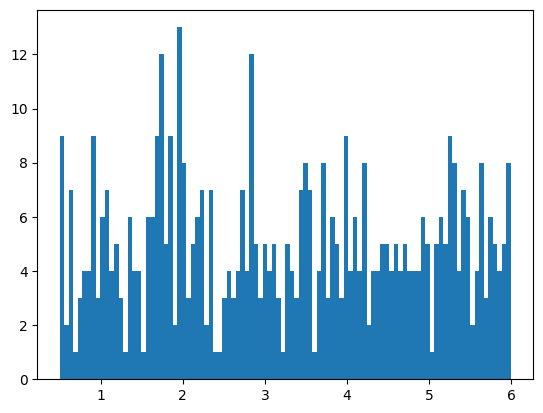

In [44]:
plt.hist(result_2026.R0_all, 100)
count = sum(x < 1 for x in result_2026.R0_all)

print(100*count/len(result_2026.R0_all))

In [45]:
# See what happens if I change k from the default 6. I tested k=4,8,10 (changing it for every iteration) on the whole time series. 
# In principle, it shouldn't change anything, as R0 is lower than k, so there's always to possibility of getting the infections. 
# Only the interpretation of \beta may change, as we explicitly have \beta * k (so, with bigger k, we should have a lower \beta (prob of transmission to the contacts)

result = fit_r0(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    n_nodes         = 150,
    incubation_days = 18.0,
    infectious_days = 10.0,
    k = 8,
)
print(f"R0 = {result.R0_estimate:.2f}  95% CI [{result.R0_ci_low:.2f}, {result.R0_ci_high:.2f}]")

  [████████████████████████████████████████]  sample 500/500  best_R0=0.607  d=0.0034
R0 = 1.10  95% CI [0.53, 2.33]


Excellent: the median value is the same, as well as the lower bound. Only the upper bound is a bit lower, so the CI is tighter. So, R0 is not sensitive to this choice, which is good.

In [46]:
# Final check: what if I perform the fit with a scale-free network?

# 1: Define network and fixed parameters
N = 150                        # Population size
m = 3                           # Barabási-Albert parameter (so that average degree is around k \sim 2*m = 6)
incubation_period = 18.0          
infectious_period = 10.0        
I_obs = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1]

network = nx.barabasi_albert_graph(N, m, seed=42)

accepted_posterior, distances = abc_rejection(
        empirical_incidence = I_obs,
        graph = network,
        incubation_period = incubation_period,
        infectious_period = infectious_period,
        prior_range=(1.0, 5.0),
        num_samples = 2000,
        tolerance= 20.0  # Adjust depending on noise tolerance
    )

Starting ABC Sampling (2000 draws)...
  Progress: 400/2000 iterations | Accepted: 400
  Progress: 800/2000 iterations | Accepted: 800
  Progress: 1200/2000 iterations | Accepted: 1200
  Progress: 1600/2000 iterations | Accepted: 1600
  Progress: 2000/2000 iterations | Accepted: 2000


In [47]:
r0_mean = np.mean(accepted_posterior)
r0_ci_lower = np.percentile(accepted_posterior, 2.5)
r0_ci_upper = np.percentile(accepted_posterior, 97.5)

print(f"Accepted Draws: {len(accepted_posterior)} / 3000")
print(f"Estimated R0:    {r0_mean:.2f} (95% CI: [{r0_ci_lower:.2f}, {r0_ci_upper:.2f}])")

Accepted Draws: 2000 / 3000
Estimated R0:    2.98 (95% CI: [1.10, 4.89])


## 2018 data (actually, cases_2020)
Cross-check, to verify that this fitting procedure gives results that are compatible with those from literature

In [48]:
# Global R value for the outbreak

result = fit_r0(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2],
    n_nodes         = 200, # the initial party had about 100 people; then, there were first contacts of these people; in any case, this is only for the long-term simulation, it does not change the fit 
    incubation_days = 18.0,
    infectious_days = 10.0,
    k = 6
)
print(f"R0 = {result.R0_estimate:.2f}  95% CI [{result.R0_ci_low:.2f}, {result.R0_ci_high:.2f}]")

  [████████████████████████████████████████]  sample 500/500  best_R0=0.881  d=0.0031
R0 = 1.09  95% CI [0.53, 1.84]


R0 = 1.09  95% CI [0.53, 1.84] on the whole outbreak is perfectly in line woth what was estimated by Martinez et al

In [49]:
# R0 only until measures were implemented (31 December, according to Martinez 2020)

result = fit_r0(
    I_obs           = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 4, 1, 1, 0, 1, 1, 1],
    n_nodes         = 200, # the initial party had about 100 people; then, there were first contacts of these people 
    incubation_days = 18.0,
    infectious_days = 10.0,
    k = 6
)
print(f"R0 = {result.R0_estimate:.2f}  95% CI [{result.R0_ci_low:.2f}, {result.R0_ci_high:.2f}]")

  [████████████████████████████████████████]  sample 500/500  best_R0=1.315  d=0.0031
R0 = 1.23  95% CI [0.63, 2.19]


R0 = 1.23 95% CI (0.63, 2.19); even in this case, it is consistent with the values from Martinez et al, good :)

## Data 1996

In [50]:
# Global R value for the outbreak (no information about measures being implemented; however, all patients were promptly isolated, so no more contacts occurred).

result_1996 = fit_r0(
    I_obs           = [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 2, 2], #, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1],
    n_nodes         = 200, # guess
    incubation_days = 18.0,
    infectious_days = 10.0,
    k = 4
)
print(f"R0 = {result_1996.R0_estimate:.2f}  95% CI [{result_1996.R0_ci_low:.2f}, {result_1996.R0_ci_high:.2f}]")

  [████████████████████████████████████████]  sample 500/500  best_R0=2.155  d=0.0027
R0 = 1.60  95% CI [0.56, 3.47]


R0 = 1.60  95% CI (0.56, 3.47). The value is compatible, but it's better not to combine it with the others, because several cases started after hospitalization of patients, which means that they were basically quarantined and their contacts drastically diminished -- it would be the same as using the overall R0 for the other outbreaks, which is not indicative of the true strength of infection at beginning, because it also combines the introduction of protective measures.

### Meta analysis: getting a unique R0 value with std
Use the inverse-variance formulas, to incorporate between-study heterogeneity, since the studies differ meaningfully.  
Assume that a Normal distribution well approximates the posteriors, then get a mean average and mean std

In [51]:
## R_0s
# I use the R0 before measures from 2026, the R0 before measures from Martinez et al. from 2018, but exclude the R0 from 1996, including their credible intervals 

R_0_2026 = result_2026.R0_estimate
R_0_1996 = result_1996.R0_estimate
R_0_2018 = 2.12 # This one is taken from the literature (so that I'm sure it's consistent with what is accepted)

low_2026 = result_2026.R0_ci_low
low_1996 = result_1996.R0_ci_low
low_2018 = 1.24

high_2026 = result_2026.R0_ci_high
high_1996 = result_1996.R0_ci_high
high_2018 = 3.35

R0s = [R_0_2026, R_0_2018]
sigmas = [(high_2026 - low_2026)/(2*1.96), (high_2018 - low_2018)/(2*1.96)]

combined_mean, combined_sd, combined_lower95, combined_upper95 = weighted_stats(R0s, sigmas)

print(f"Combined R0 = {combined_mean:.2f}, Combined std = {combined_sd:.2f},  95% CI [{combined_lower95:.2f}, {combined_upper95:.2f}]")


Combined R0 = 2.30, Combined std = 0.49,  95% CI [1.33, 3.27]


Combined R0 = 2.30, Combined std = 0.49,  95% CI (1.33, 3.27). This is a final value for R0 of Hantavirus, coming from different outbreaks and studies. It is reasonable, rather close to that of COVID-19, and embeds \beta*k and the incubation period \gamma^-1

In [52]:
sigmas

[1.2471597847558429, 0.538265306122449]